In [265]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [266]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [267]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [268]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [269]:
df = df.sort_values('datetime').reset_index(drop=True)


In [270]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station','pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility',  'aqi']]

In [271]:
df

,year,month,day,hour,is_weekend,season,station,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",371.8,739.4,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",248.2,424.5,94.7,16.4,4.38,24.5,8.3,100,3.6,1.7,399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500
3,2020,1,1,6,0,winter,Noida Sec 125,266.3,572.8,86.0,18.6,3.26,20.9,9.4,100,3.5,2.9,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",269.8,488.6,89.8,15.9,4.23,21.5,7.4,100,3.4,2.6,473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,340.1,600.4,138.7,27.6,5.17,14.8,14.8,48,6.8,0.8,500
201660,2025,12,31,23,0,winter,Noida Sec 125,249.2,501.2,93.0,14.4,3.12,28.2,15.7,51,6.2,2.3,489
201661,2025,12,31,23,0,winter,Greater Noida,264.0,568.9,92.2,15.5,4.07,23.3,16.0,54,4.3,2.7,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",440.1,816.5,167.1,54.9,5.45,12.9,17.7,64,6.5,1.0,500


In [272]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [273]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
2,2020,1,1,6,0,winter,327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500
25,2020,1,1,12,0,winter,231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408
67,2020,1,1,18,0,winter,271.6,483.2,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,466
70,2020,1,1,23,0,winter,324.8,655.0,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,500
98,2020,1,2,6,0,winter,350.2,636.3,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500
201578,2025,12,31,6,0,winter,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500
201597,2025,12,31,12,0,winter,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349
201627,2025,12,31,18,0,winter,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426


In [274]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [275]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [276]:
df1

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500,False,False,True
25,2020,1,1,12,0,231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408,False,False,True
67,2020,1,1,18,0,271.6,483.2,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,466,False,False,True
70,2020,1,1,23,0,324.8,655.0,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,500,False,False,True
98,2020,1,2,6,0,350.2,636.3,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,500,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500,False,False,True
201578,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500,False,False,True
201597,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349,False,False,True
201627,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426,False,False,True


In [277]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [278]:
df1.isna().sum()

year                    0
month                   0
day                     0
hour                    0
is_weekend              0
pm25                    0
pm10                    0
no2                     0
so2                     0
co                      0
o3                      0
temperature             0
humidity                0
wind_speed              0
visibility              0
aqi                     0
season_post_monsoon     0
season_summer           0
season_winter           0
aqi_lag_1               1
aqi_lag_2               2
aqi_lag_4               4
aqi_lag_8               8
aqi_lag_28             28
dtype: int64

In [279]:
df1 = df1.dropna().reset_index(drop=True)


In [280]:
feature_cols = [
    'pm25','pm10','no2','so2','co','o3',
    'temperature','humidity','wind_speed','visibility',
    'year', 'month', 'day', 'hour', 'is_weekend',
    'season_winter','season_summer','season_post_monsoon','aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'
]

In [281]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]


X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df['aqi'].values.reshape(-1,1)
y_test  = test_df['aqi'].values.reshape(-1,1)
# ==========================
# 3. SCALING
# ==========================

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test  = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [282]:
TIMESTEPS = 24   # 1-day window (adjust if needed)

def create_sequences(X, y, t):
    X_seq, y_seq = [], []
    for i in range(len(X) - t):
        X_seq.append(X[i:i+t])
        y_seq.append(y[i+t])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test_scaled, TIMESTEPS)


In [231]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

C:\Users\Dhruv\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.2545 - mae: 0.2545 - val_loss: 0.3407 - val_mae: 0.3407 - learning_rate: 0.0010
Epoch 2/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2716 - mae: 0.2716 - val_loss: 0.2004 - val_mae: 0.2004 - learning_rate: 0.0010
Epoch 3/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2077 - mae: 0.2077 - val_loss: 0.1811 - val_mae: 0.1811 - learning_rate: 0.0010
Epoch 4/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1789 - mae: 0.1789 - val_loss: 0.1776 - val_mae: 0.1776 - learning_rate: 0.0010
Epoch 5/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1794 - mae: 0.1794 - val_loss: 0.2489 - val_mae: 0.2489 - learning_rate: 0.0010
Epoch 6/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1734 - mae: 0.1734 - val_loss: 0.1772 - val_mae: 0.1772 - learning_rate: 0.0010
Epoch 7/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1654 - mae: 0.1654 - val_loss: 0.1517 - val_mae: 0.1517 - learning_rate

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict
y_pred_lstm = model.predict(X_test_seq)

# inverse scale FIRST (keep 2D shape)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm)
y_test_actual = y_scaler.inverse_transform(y_test_seq)

# flatten for metrics
y_pred_lstm = y_pred_lstm.flatten()
y_test_actual = y_test_actual.flatten()

# metrics on real AQI values
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, y_pred_lstm)
print("LSTM R2:", r2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
LSTM MAE: 22.04699446696757
LSTM RMSE: 30.584427420415857
LSTM R2: 0.9670793508397688


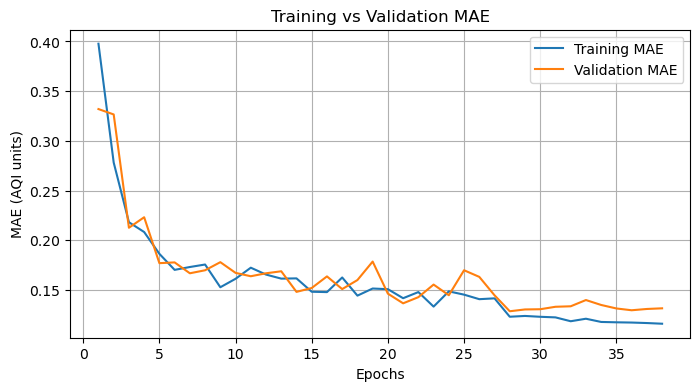

In [167]:
epochs = range(1, len(history.history['mae']) + 1)

plt.figure(figsize=(8, 4))

plt.plot(epochs, history.history['mae'], label='Training MAE')
plt.plot(epochs, history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('MAE (AQI units)')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()


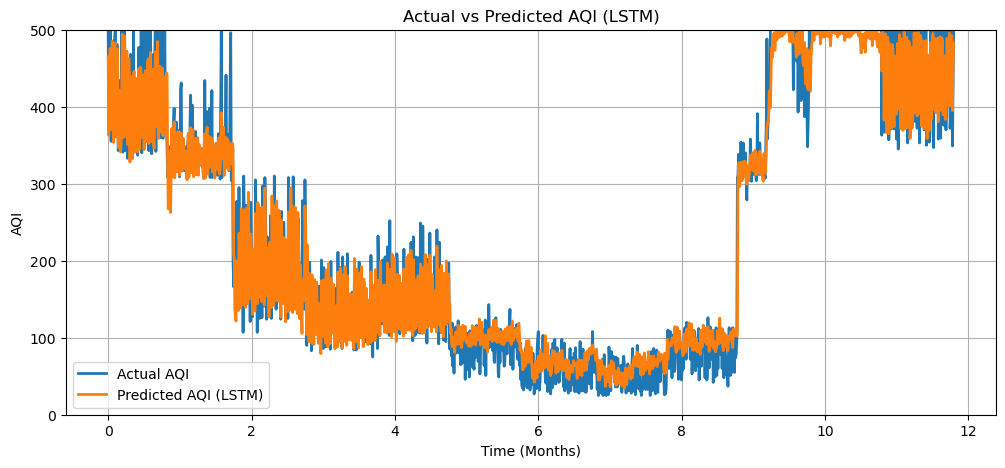

In [168]:
plt.figure(figsize=(12, 5))

# clip predictions to AQI range
y_pred_lstm = np.clip(y_pred_lstm, 0, 500)

# use correct length (same as plotted data)
n_samples = len(y_test_actual)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months, y_test_actual, label='Actual AQI', linewidth=2)
plt.plot(x_months, y_pred_lstm, label='Predicted AQI (LSTM)', linewidth=2)

# keep axis consistent with AQI definition
plt.ylim(0, 500)

plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI (LSTM)')
plt.legend()
plt.grid(True)

plt.savefig("lstm_actual_vs_predicted.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [283]:
X_test_no_poll = test_df[feature_cols].copy()

pollutant_cols = [
    'pm25','pm10','no2','so2','co','o3',
    'temperature','humidity','wind_speed','visibility'
]

X_test_no_poll[pollutant_cols] = 0

X_test_no_poll = X_scaler.transform(X_test_no_poll.values)

X_test_no_poll_seq, _ = create_sequences(
    X_test_no_poll,
    y_test_scaled,
    TIMESTEPS
)

y_pred_no_poll_scaled = model.predict(X_test_no_poll_seq)
y_pred_no_poll = y_scaler.inverse_transform(y_pred_no_poll_scaled)

mae_no_poll = mean_absolute_error(y_test_actual, y_pred_no_poll)
rmse_no_poll = np.sqrt(mean_squared_error(y_test_actual, y_pred_no_poll))

print("\nWITHOUT POLLUTANTS LSTM")
print("MAE:", mae_no_poll)
print("RMSE:", rmse_no_poll)

from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, y_pred_no_poll)
print(" R2:", r2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

WITHOUT POLLUTANTS LSTM
MAE: 103.98030154087418
RMSE: 117.58206760546285
 R2: 0.5134249150399641


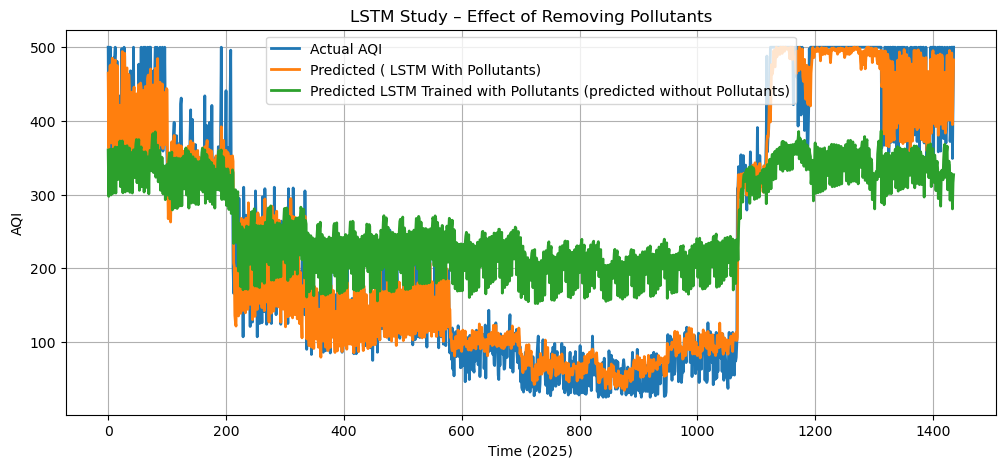

In [284]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label="Actual AQI", linewidth=2)
plt.plot(y_pred_lstm, label="Predicted ( LSTM With Pollutants)", linewidth=2)
plt.plot(y_pred_no_poll, label="Predicted LSTM Trained with Pollutants (predicted without Pollutants)", linewidth=2)

plt.title("LSTM Study – Effect of Removing Pollutants")
plt.xlabel("Time (2025)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()

In [286]:
df1=df1.drop(columns=['aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'])

In [287]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

drop_cols = ['aqi']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']

In [288]:
df1

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,season_post_monsoon,season_summer,season_winter
0,2020,1,8,6,0,367.1,648.7,108.9,26.3,5.68,14.2,8.3,100,4.0,0.5,500,False,False,True
1,2020,1,8,12,0,221.7,428.5,76.4,13.4,3.29,27.1,17.4,47,7.8,2.5,398,False,False,True
2,2020,1,8,18,0,228.5,375.6,129.2,16.8,4.81,26.8,15.8,64,4.8,2.1,383,False,False,True
3,2020,1,8,23,0,292.3,637.7,94.5,26.8,4.07,29.3,12.1,62,4.6,2.2,500,False,False,True
4,2020,1,9,6,0,268.0,545.5,96.8,22.7,4.47,26.8,7.5,95,2.2,3.0,500,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500,False,False,True
8736,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500,False,False,True
8737,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349,False,False,True
8738,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426,False,False,True


In [289]:
df1.columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'pm25', 'pm10', 'no2',
       'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'aqi', 'season_post_monsoon', 'season_summer',
       'season_winter'],
      dtype='object')

In [290]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [291]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
from sklearn.metrics import r2_score

r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost MAE: 0.9287459850311279
XGBoost RMSE: 1.4519316172142145
XGBoost R2: 0.9999258518218994


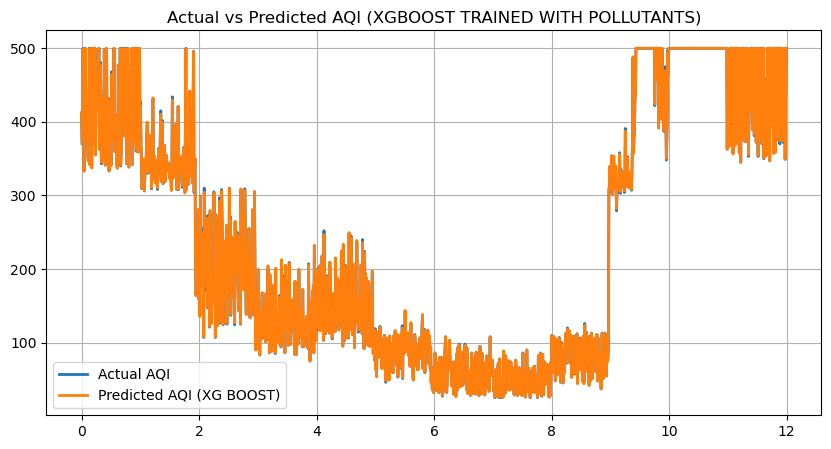

In [292]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred_xgb, label="Predicted AQI (XG BOOST)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (XGBOOST TRAINED WITH POLLUTANTS)")
plt.show()

In [294]:
import numpy as np
import matplotlib.pyplot as plt

# Convert everything to numpy arrays
y_actual = np.array(y_test_actual)

y_xgb    = np.array(y_pred_xgb)
y_lstm   = np.array(y_pred_lstm)
y_no_lstm   = np.array(y_pred_no_poll)


# Find minimum length
min_len = min(len(y_actual), len(y_lstm), len(y_xgb),len(y_pred_no_poll))

# Align from the END (important for time series)
y_actual = y_actual[-min_len:]
y_lstm   = y_lstm[-min_len:]
y_xgb    = y_xgb[-min_len:]
y_no_lstm = y_no_lstm[-min_len:]

# X-axis
x_months = np.arange(min_len) / 121.66


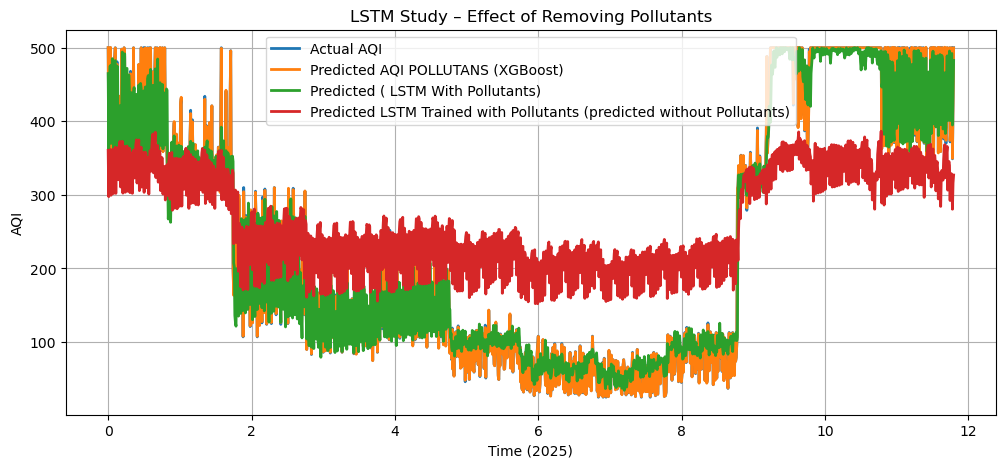

In [295]:
plt.figure(figsize=(12,5))

n_samples = len(y_actual)

x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_actual, label="Actual AQI", linewidth=2)
plt.plot(x_months, y_xgb, label='Predicted AQI POLLUTANS (XGBoost)', linewidth=2)
plt.plot(x_months,y_lstm, label="Predicted ( LSTM With Pollutants)", linewidth=2)
plt.plot(x_months , y_no_lstm, label="Predicted LSTM Trained with Pollutants (predicted without Pollutants)", linewidth=2)



plt.title("LSTM Study – Effect of Removing Pollutants")
plt.xlabel("Time (2025)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()

In [296]:
df1.columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'pm25', 'pm10', 'no2',
       'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'aqi', 'season_post_monsoon', 'season_summer',
       'season_winter'],
      dtype='object')

In [297]:
feature_cols = ['year', 'month', 'day', 'hour', 'is_weekend', 'pm25', 'pm10', 'no2',
       'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'season_post_monsoon', 'season_summer', 'season_winter']

In [298]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

drop_cols = ['aqi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']


In [299]:
# Make a copy of test data
X_test_no_poll = test_df[feature_cols].copy()

# Define pollutant + weather columns
pollutant_cols = [
    'pm25','pm10','no2','so2','co','o3',
    'temperature','humidity','wind_speed','visibility'
]

# 🔴 Remove pollutant signal
X_test_no_poll[pollutant_cols] = 0



# Predict directly (NO sequences)
y_xgb_no_poll = xgb.predict(X_test_no_poll)

# Evaluate
mae_no_poll = mean_absolute_error(y_test, y_xgb_no_poll)
rmse_no_poll = np.sqrt(mean_squared_error(y_test, y_xgb_no_poll))

print("\nWITHOUT POLLUTANTS (XGBoost)")
print("MAE:", mae_no_poll)
print("RMSE:", rmse_no_poll)
from sklearn.metrics import r2_score

r2_xgb = r2_score(y_test, y_xgb_no_poll)
print("XGBoost R2:", r2_xgb)



WITHOUT POLLUTANTS (XGBoost)
MAE: 214.33013916015625
RMSE: 272.7304071789576
XGBoost R2: -1.6155004501342773


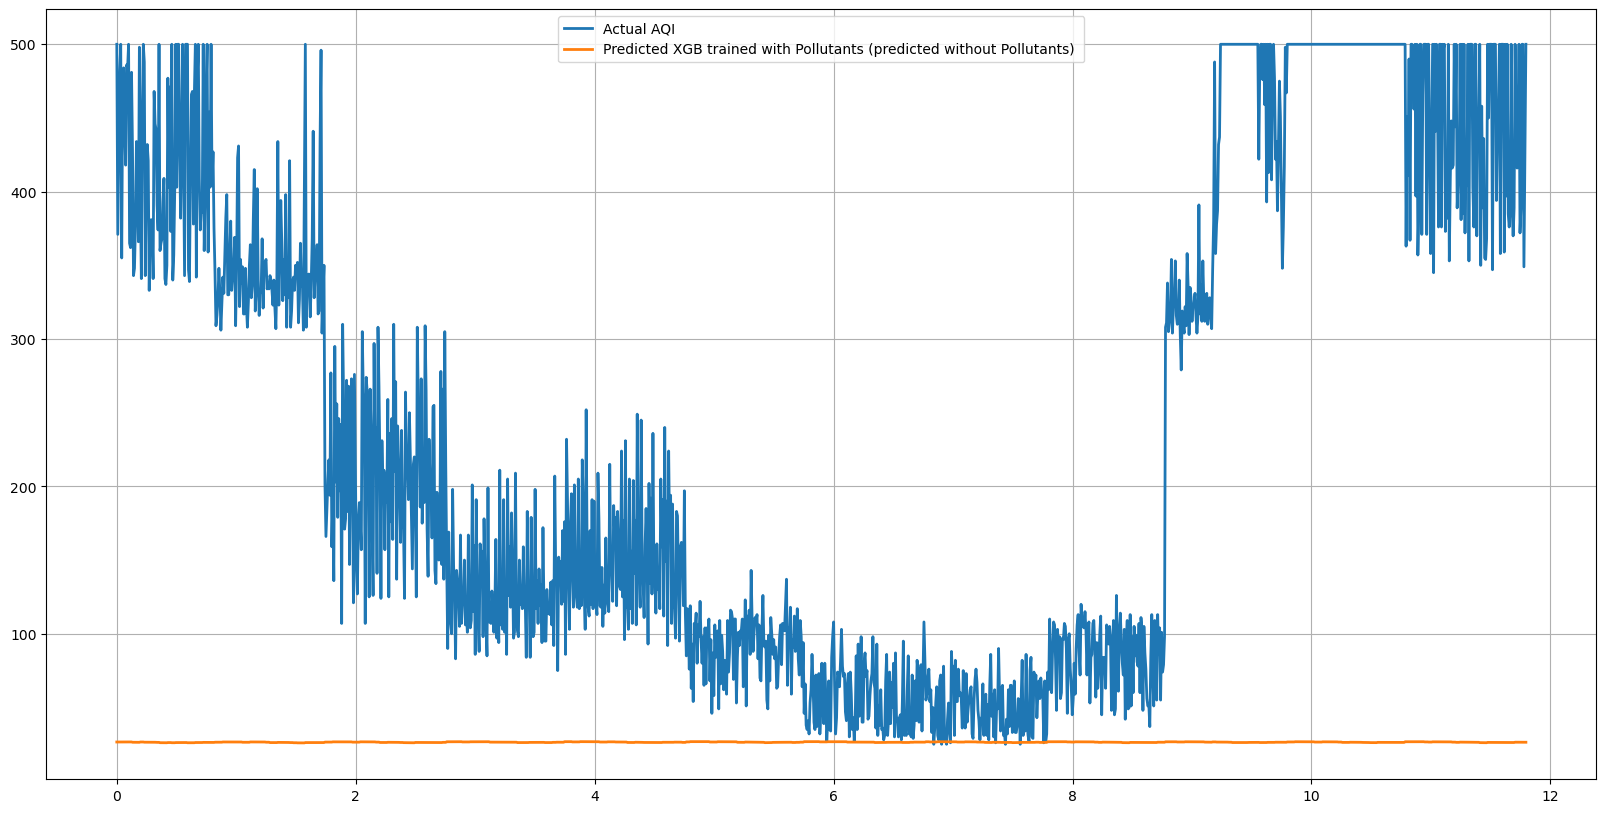

In [308]:
plt.figure(figsize=(20,10))

n_samples = len(y_actual)

x_months = np.arange(n_samples) / 121.66
plt.plot(x_months,y_actual, label="Actual AQI", linewidth=2)
plt.plot(x_months , y_xgb_no_poll, label="Predicted XGB trained with Pollutants (predicted without Pollutants) ", linewidth=2)
plt.legend()
plt.grid(True)

plt.show()

In [300]:
import numpy as np
import matplotlib.pyplot as plt

# Convert everything to numpy arrays
y_actual = np.array(y_test_actual)

y_xgb    = np.array(y_pred_xgb)
y_lstm   = np.array(y_pred_lstm)
y_no_lstm   = np.array(y_pred_no_poll)
y_xgb_no_poll = np.array(y_xgb_no_poll)

# Find minimum length
min_len = min(len(y_actual), len(y_lstm), len(y_xgb),len(y_pred_no_poll),len(y_xgb_no_poll))

# Align from the END (important for time series)
y_actual = y_actual[-min_len:]
y_lstm   = y_lstm[-min_len:]
y_xgb    = y_xgb[-min_len:]
y_no_lstm = y_no_lstm[-min_len:]
y_xgb_no_poll = y_xgb_no_poll[-min_len:]

# X-axis
x_months = np.arange(min_len) / 121.66


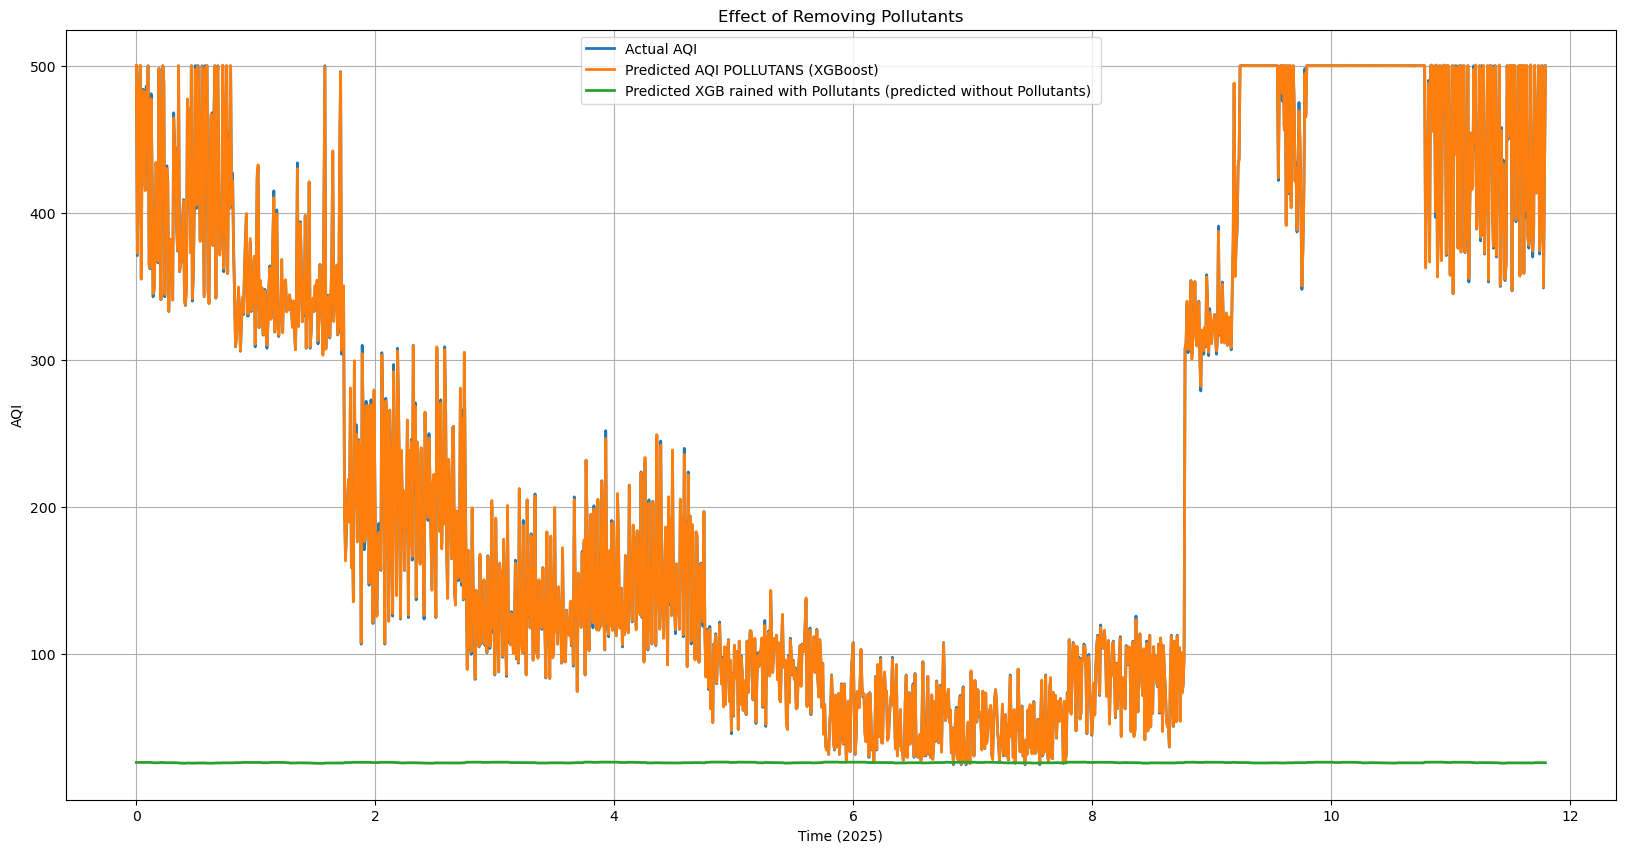

In [301]:
plt.figure(figsize=(20,10))

n_samples = len(y_actual)

x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_actual, label="Actual AQI", linewidth=2)
plt.plot(x_months, y_xgb, label='Predicted AQI POLLUTANS (XGBoost)', linewidth=2)

plt.plot(x_months , y_xgb_no_poll, label="Predicted XGB rained with Pollutants (predicted without Pollutants) ", linewidth=2)



plt.title("Effect of Removing Pollutants")
plt.xlabel("Time (2025)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()

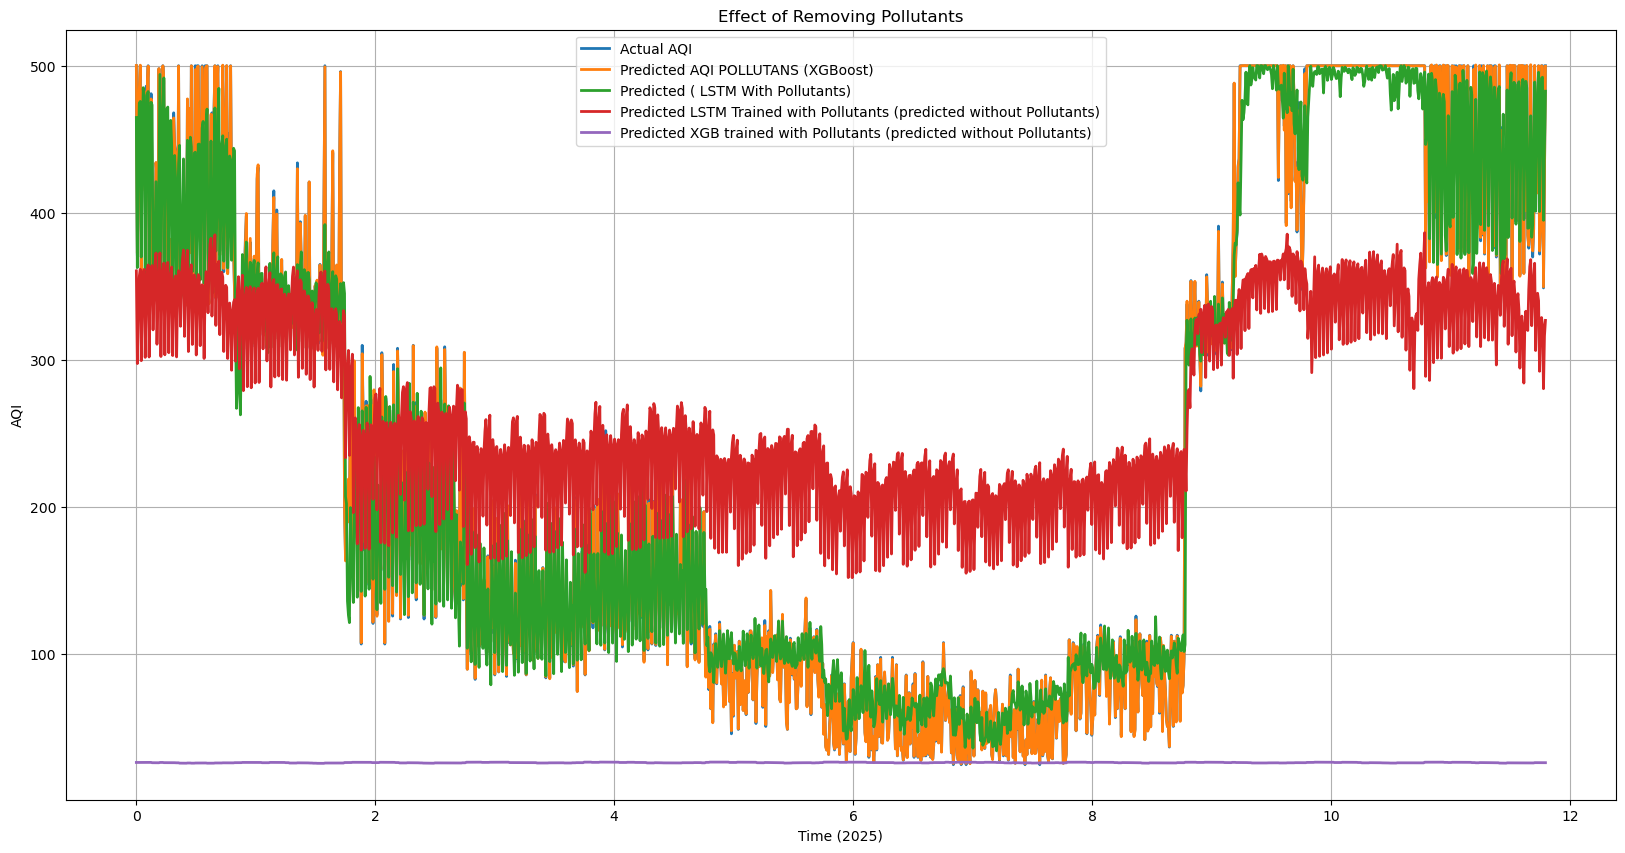

In [302]:
plt.figure(figsize=(20,10))

n_samples = len(y_actual)

x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_actual, label="Actual AQI", linewidth=2)
plt.plot(x_months, y_xgb, label='Predicted AQI POLLUTANS (XGBoost)', linewidth=2)
plt.plot(x_months,y_lstm, label="Predicted ( LSTM With Pollutants)", linewidth=2)
plt.plot(x_months , y_no_lstm, label="Predicted LSTM Trained with Pollutants (predicted without Pollutants)", linewidth=2)
plt.plot(x_months , y_xgb_no_poll, label="Predicted XGB trained with Pollutants (predicted without Pollutants) ", linewidth=2)



plt.title("Effect of Removing Pollutants")
plt.xlabel("Time (2025)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.savefig("actual_vs_predicted2.jpg", dpi=300, bbox_inches="tight")
plt.show()